# Pupil dynamic

In [1]:

import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns
from statsmodels.nonparametric.smoothers_lowess import lowess
import pymc as pm
import arviz as az
import xarray as xr
from IPython.display import display

rng = np.random.default_rng(seed=42)
print(f"Running on PyMC v{pm.__version__}")

WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


Running on PyMC v5.16.1


copenhagen 31.09 = 100 micron

In [2]:
group_colors = {
    'male': '#D7301F', 
    'female': '#F4A40B', 
    'atoke': '#654321' 
}

Pupil dynamic measures from Exeter

scale	0.55	µm is one pixel	
182	pixels = 	100	µm

Feret's diameter:The longest distance between any two points along the selection boundary, also known as maximum caliper. MinFeret is the minimum caliper diameter. 

The values in the CSV are in pixels. We convert these to microns.

In [3]:
pupils_df = pd.read_csv('../data/pupils.csv', sep = ',')
pupils_df.tail()

,group,id,side,time,major,minor,feret,minFeret,angle
62,atoke,cph_atoke,Anterior,30,30.685,22.199,30.767,22.149,42.467
63,atoke,cph_atoke,Posterior,0,13.406,7.978,13.633,7.850,161.837
64,atoke,cph_atoke,Posterior,10,16.872,11.018,16.722,11.210,166.968
65,atoke,cph_atoke,Posterior,20,18.104,13.855,18.105,13.963,168.338
66,atoke,cph_atoke,Posterior,30,23.887,16.311,23.806,16.385,173.144


In [4]:
# Load the data and exclude times exceeding 35 minutes. 
pupils_df = pupils_df[pupils_df['time'] <= 35]
pupils_df['eye'] = pupils_df['id'] + '_' + pupils_df['side']
# multiply the distances by the column px_to_um in the dataframe
# Multiply the relevant columns by 'px_to_um' and update them in the dataframe
for col in ['major', 'minor', 'feret', 'minFeret']:
    pupils_df[col] = pupils_df[col] * pupils_df['px_to_um']
pupils_df.tail()

KeyError: 'px_to_um'

In [ ]:
# Group by 'id' and calculate the mean for the 'major' column
pupils_df_grouped = pupils_df.groupby(['id'])['major'].mean().reset_index()

# Display the grouped DataFrame
pupils_df_grouped

,id,major
0,atoke1,32.246159
1,atoke2,35.263483
2,atoke3,44.094853
3,cph_atoke,51.519062
4,cph_male,58.556452
5,female1,55.235791
6,female2,56.300286
7,female3,34.871633
8,male1,23.016618
9,male2,83.715836


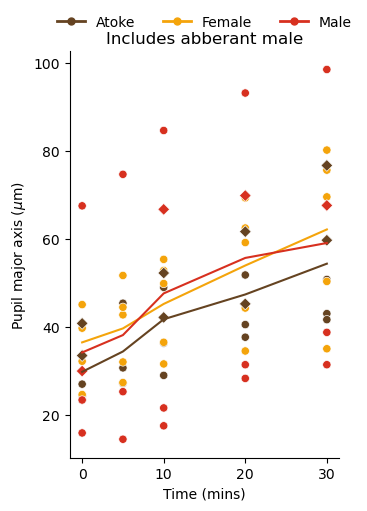

In [ ]:
# Ensure 'group' is a categorical variable and matches the group_colors dictionary keys
pupils_df['group'] = pupils_df['group'].astype('category')

# Flag Copenhagen eyes so we can plot them with a distinct marker
pupils_df['eye_marker'] = np.where(pupils_df['eye'].str.startswith('cph_'), 'cph', 'other')
marker_map = {'other': 'o', 'cph': 'D'}

# Create a relplot with increased width
g = sns.relplot(
    data=pupils_df,
    x='time',
    y='major',
    hue='group',
    style='eye_marker',
    style_order=['other', 'cph'],
    markers=marker_map,
    height=4.8,
    aspect=0.75,
    palette=group_colors
)

# Add a lineplot on the relplot using the group_colors dictionary
g.map_dataframe(sns.lineplot, 'time', 'major', hue='group', estimator='mean', err_style=None, palette=group_colors)

# Remove the original legend if it exists
if g._legend is not None:
    g._legend.remove()

# Define custom legend handles using the group_colors palette
legend_handles = [Line2D([0], [0], color=group_colors[group], marker='o', markersize=5, linestyle='-', linewidth=2) for group in ['atoke', 'female', 'male']]

# Add a new legend with custom handles and no outer box
plt.legend(handles=legend_handles, labels=['Atoke', 'Female', 'Male'], loc='upper center', bbox_to_anchor=(0.5, 1.12), ncol=3, frameon=False)

# Set axis labels
plt.xlabel('Time (mins)')
plt.ylabel(r'Pupil major axis ($\mu$m)')
plt.title('Includes aberrant male')

# Show the plot
plt.show()

There is one male outlier which far exceeds all other data.

In [ ]:
# Remove the outlier 'male2' from the DataFrame
pupils_df = pupils_df.loc[pupils_df['id'] != 'male2'].copy()

In [ ]:
pupils_df['eye'].value_counts()

eye
atoke1_only            5
atoke2_only            5
atoke3_only            5
female1_only           5
female2_left           5
female2_right          5
female3_left           5
female3_right          5
male1_only             5
male3_only             5
cph_male_Anterior      4
cph_atoke_Anterior     4
cph_atoke_Posterior    4
Name: count, dtype: int64

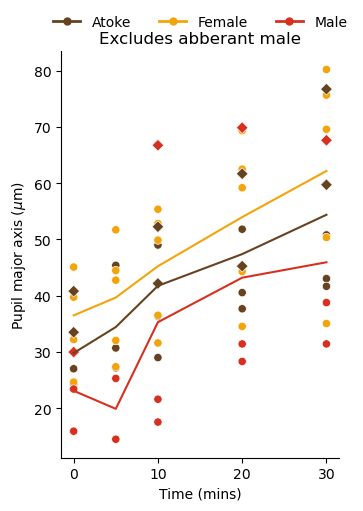

In [ ]:
# Ensure 'group' is a categorical variable and matches the group_colors dictionary keys
pupils_df['group'] = pupils_df['group'].astype('category')

# Flag Copenhagen eyes so we can plot them with a distinct marker
pupils_df['eye_marker'] = np.where(pupils_df['eye'].str.startswith('cph_'), 'cph', 'other')
marker_map = {'other': 'o', 'cph': 'D'}

# Create a relplot with increased width
g = sns.relplot(
    data=pupils_df,
    x='time',
    y='major',
    hue='group',
    style='eye_marker',
    style_order=['other', 'cph'],
    markers=marker_map,
    height=4.8,
    aspect=0.75,
    palette=group_colors
)

# Add a lineplot on the relplot using the group_colors dictionary
g.map_dataframe(sns.lineplot, 'time', 'major', hue='group', estimator='mean', err_style=None, palette=group_colors)

# Remove the original legend if it exists
if g._legend is not None:
    g._legend.remove()

# Define custom legend handles using the group_colors palette
legend_handles = [Line2D([0], [0], color=group_colors[group], marker='o', markersize=5, linestyle='-', linewidth=2) for group in ['atoke', 'female', 'male']]

# Add a new legend with custom handles and no outer box
plt.legend(handles=legend_handles, labels=['Atoke', 'Female', 'Male'], loc='upper center', bbox_to_anchor=(0.5, 1.12), ncol=3, frameon=False)

# Set axis labels
plt.xlabel('Time (mins)')
plt.ylabel(r'Pupil major axis ($\mu$m)')
# plt.title('Excludes aberrant male')
plt.savefig('../figs/fig3.pdf', dpi=300, bbox_inches='tight')
# Show the plot
plt.show()

In [ ]:
# Select numeric columns excluding 'time'
numeric_cols = pupils_df.select_dtypes(include=np.number).columns.tolist()
numeric_cols.remove('time')

# Check for existing combinations of 'group' and 'id'
existing_combinations = pupils_df[['group', 'id']].drop_duplicates()

# Group by 'time', 'group', 'id', and calculate mean of numeric columns
pupils_df_grouped = (
    pupils_df.groupby(['time', 'group', 'id'], as_index=False)[numeric_cols].mean()
)

# Ensure the result only contains existing 'group' and 'id' combinations, and no new combinations are introduced
pupils_df_grouped = pupils_df_grouped.merge(existing_combinations, on=['group', 'id'])

# Verify the result
pupils_df_grouped.head()

/tmp/ipykernel_859716/4246957924.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pupils_df.groupby(['time', 'group', 'id'], as_index=False)[numeric_cols].mean()


,time,group,id,major,minor,feret,minFeret,angle,px_to_um
0,0,atoke,atoke1,24.306533,19.953648,24.813149,20.089080,NaN,0.5016
1,0,atoke,atoke2,27.022195,17.830375,26.714714,17.728550,NaN,0.5016
2,0,atoke,atoke3,23.419704,20.449730,23.660472,20.468290,NaN,0.5016
3,0,atoke,cph_atoke,37.168750,23.520000,37.626250,23.238750,109.2745,2.5000
4,0,female,female1,40.831243,33.383486,42.434858,34.248245,NaN,0.5016


In [ ]:
# Display the first few rows of the dataframe
pupils_df['W_scaled'] = (pupils_df['major'] - pupils_df['major'].mean()) / pupils_df['major'].std()
pupils_df['T_scaled'] = (pupils_df['time'] - pupils_df['time'].mean()) / pupils_df['time'].std()
pupils_df.head()

,group,id,side,time,major,minor,feret,minFeret,angle,px_to_um,eye,W_scaled,T_scaled
0,atoke,atoke1,only,0,24.306533,19.953648,24.813149,20.089080,NaN,0.5016,atoke1_only,-1.137443,-1.220510
1,atoke,atoke1,only,5,27.188726,13.702709,26.590819,13.476989,NaN,0.5016,atoke1_only,-0.958139,-0.764657
2,atoke,atoke1,only,10,29.008531,16.498627,29.336578,16.929000,NaN,0.5016,atoke1_only,-0.844928,-0.308804
3,atoke,atoke1,only,20,37.684706,24.278443,38.404001,24.578400,NaN,0.5016,atoke1_only,-0.305176,0.602903
4,atoke,atoke1,only,30,43.042296,27.426485,42.991634,27.588000,NaN,0.5016,atoke1_only,0.028124,1.514609


In [ ]:
# eye diameter min, max, and range by group
major_stats_by_group = (
    pupils_df
        .groupby('group')['major']
        .agg(min_major='min', max_major='max', major_range=lambda s: s.max() - s.min())
        .reset_index()
)
major_stats_by_group

/tmp/ipykernel_859716/3059159769.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('group')['major']


,group,min_major,max_major,major_range
0,atoke,23.419704,76.712500,53.292796
1,female,24.649126,80.206843,55.557718
2,male,14.499250,69.867742,55.368492


In [ ]:
pupils_df.describe()

,time,major,minor,feret,minFeret,angle,px_to_um,W_scaled,T_scaled
count,62.000000,62.000000,62.000000,62.000000,62.000000,12.000000,62.000000,6.200000e+01,6.200000e+01
mean,13.387097,42.590225,32.325114,43.285303,32.533349,123.470833,0.935213,-1.539987e-16,3.939501e-17
std,10.968442,16.074383,13.035563,16.214478,13.126895,53.348995,0.905147,1.000000e+00,1.000000e+00
min,0.000000,14.499250,10.940899,14.546400,11.035200,42.467000,0.501600,-1.747562e+00,-1.220510e+00
25%,5.000000,30.895676,21.596137,31.403170,21.911142,58.359750,0.501600,-7.275271e-01,-7.646571e-01
50%,10.000000,40.826872,29.685691,41.487500,29.601673,147.954000,0.501600,-1.096996e-01,-3.088038e-01
75%,20.000000,51.795216,40.650613,53.172061,40.890561,163.119750,0.501600,5.726497e-01,6.029027e-01
max,30.000000,80.206843,63.757373,81.081132,63.201600,173.144000,3.225806,2.340159e+00,1.514609e+00


In [ ]:

# Compute within-eye max/min ratios, filter invalid cases, and keep group labels for modelling
ratios_df = (
    pupils_df
    .groupby(['eye', 'group'])
    .agg(min_major=('major', 'min'), max_major=('major', 'max'))
    .reset_index()
)
ratios_df = ratios_df.loc[ratios_df['min_major'] > 0].copy()
ratios_df['ratio'] = ratios_df['max_major'] / ratios_df['min_major']
ratios_df['log_ratio'] = np.log(ratios_df['ratio'])
ratios_df = (
    ratios_df
    .replace([np.inf, -np.inf], np.nan)
    .dropna(subset=['log_ratio'])
    .sort_values(by='ratio', ascending=False)
)
ratios_df

/tmp/ipykernel_859716/3885096366.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['eye', 'group'])


,eye,group,min_major,max_major,ratio,log_ratio
35,male1_only,male,14.499250,38.782709,2.674808,0.983878
17,cph_male_Anterior,male,29.990323,69.867742,2.329676,0.845729
6,atoke3_only,atoke,23.419704,51.822302,2.212765,0.794243
19,female1_only,female,40.831243,80.206843,1.964350,0.675161
25,female2_right,female,39.743273,75.654823,1.903588,0.643741
9,cph_atoke_Anterior,atoke,40.822500,76.712500,1.879172,0.630831
12,cph_atoke_Posterior,atoke,33.515000,59.717500,1.781814,0.577632
0,atoke1_only,atoke,24.306533,43.042296,1.770812,0.571438
31,female3_right,female,32.053745,50.353618,1.570912,0.451656
22,female2_left,female,45.095846,69.570415,1.542723,0.433549


In [ ]:
# Specify HMC conditions to be applied in modelling
ndraws = 2500
ntune  = 2500

# Encode group membership for each eye-level log-ratio observation
group_codes, group_labels = pd.factorize(ratios_df['group'], sort=True)
log_ratio_values = ratios_df['log_ratio'].values
log_ratio_mean = np.mean(log_ratio_values)
log_ratio_std = np.std(log_ratio_values, ddof=0)
if not np.isfinite(log_ratio_std) or log_ratio_std == 0:
    log_ratio_std = 1.0

with pm.Model() as m_ratio:
    mu_group = pm.Normal('mu_group', mu=log_ratio_mean, sigma=log_ratio_std * 2, shape=len(group_labels))
    sigma = pm.HalfNormal('sigma', sigma=log_ratio_std)
    log_ratio_obs = pm.Normal('log_ratio_obs', mu=mu_group[group_codes], sigma=sigma, observed=log_ratio_values)

pm.model_to_graphviz(m_ratio)

Sampling: [log_ratio_obs, mu_group, sigma]


<Axes: xlabel='log_ratio_obs'>

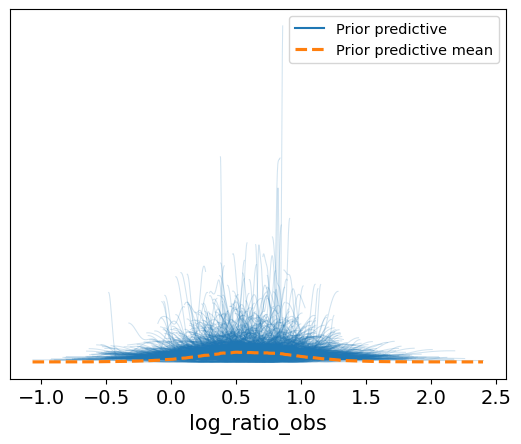

In [ ]:
# prior predictive check
with m_ratio:
    idata = pm.sample_prior_predictive(samples=1000, random_seed=rng)

az.plot_ppc(idata, group="prior", kind="kde", data_pairs={"log_ratio_obs": "log_ratio_obs"})

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_group, sigma]


Output()

Sampling 4 chains for 2_500 tune and 2_500 draw iterations (10_000 + 10_000 draws total) took 6 seconds.


array([[<Axes: title={'center': 'mu_group'}>,
        <Axes: title={'center': 'mu_group'}>],
       [<Axes: title={'center': 'sigma'}>,
        <Axes: title={'center': 'sigma'}>]], dtype=object)

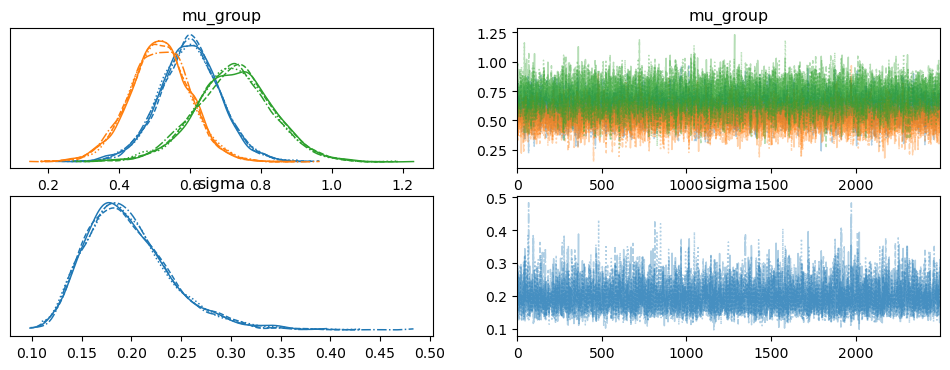

In [ ]:
with m_ratio:
    idata.extend(pm.sample(ndraws, tune=ntune, random_seed=rng))

idata.posterior = idata.posterior.assign_coords(mu_group_dim_0=group_labels)
az.plot_trace(idata, var_names=['mu_group', 'sigma'])

In [ ]:
# Summarize posterior group-level ratios and compute pairwise contrasts post hoc on the ratio scale
posterior_mu = idata.posterior['mu_group']
posterior_ratio = np.exp(posterior_mu)
pairwise_diffs = {}
for i, left in enumerate(group_labels):
    for j, right in enumerate(group_labels):
        if j <= i:
            continue
        diff_key = f"{left}_minus_{right}"
        pairwise_diffs[diff_key] = posterior_ratio.sel(mu_group_dim_0=left) - posterior_ratio.sel(mu_group_dim_0=right)

mu_summary = (
    az.summary(posterior_ratio, hdi_prob=0.95)
    .assign(group=group_labels)
    [['group', 'mean', 'sd', 'hdi_2.5%', 'hdi_97.5%']]
    .rename(columns={'mean': 'ratio_mean', 'sd': 'ratio_sd', 'hdi_2.5%': 'hdi_2.5', 'hdi_97.5%': 'hdi_97.5'})
)

if pairwise_diffs:
    diff_ds = xr.Dataset(pairwise_diffs)
    ratio_diff_summary = (
        az.summary(diff_ds, hdi_prob=0.95)
        [['mean', 'sd', 'hdi_2.5%', 'hdi_97.5%']]
        .rename(columns={'mean': 'difference_mean', 'sd': 'difference_sd', 'hdi_2.5%': 'hdi_2.5', 'hdi_97.5%': 'hdi_97.5'})
    )
    ratio_diff_summary.index.name = 'comparison'

    probability_direction = {
        name: float((diff_ds[name].values > 0).mean())
        for name in diff_ds.data_vars
    }
    ratio_diff_summary['pd'] = ratio_diff_summary.index.map(probability_direction)
else:
    ratio_diff_summary = pd.DataFrame(columns=['difference_mean', 'difference_sd', 'hdi_2.5', 'hdi_97.5', 'pd'])

display(mu_summary)
if not ratio_diff_summary.empty:
    display(ratio_diff_summary)

,group,ratio_mean,ratio_sd,hdi_2.5,hdi_97.5
mu_group[atoke],atoke,1.830,0.159,1.509,2.137
mu_group[female],female,1.681,0.145,1.390,1.960
mu_group[male],male,2.073,0.230,1.629,2.538


,difference_mean,difference_sd,hdi_2.5,hdi_97.5,pd
comparison,,,,,
atoke_minus_female,0.149,0.214,-0.273,0.572,0.7691
atoke_minus_male,-0.243,0.278,-0.818,0.284,0.1793
female_minus_male,-0.392,0.274,-0.953,0.124,0.0696


/tmp/ipykernel_859716/1409323613.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


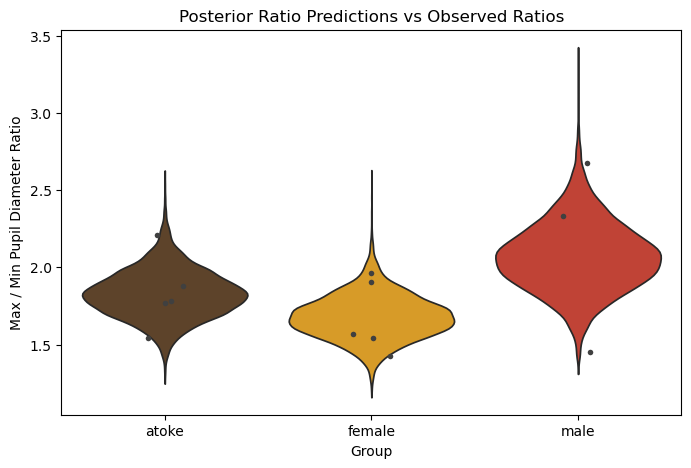

In [ ]:
# Visualize posterior ratio predictions against observed ratios by group
posterior_ratio_df = (
    posterior_ratio
    .to_dataframe(name='posterior_ratio')
    .reset_index()
    .rename(columns={'mu_group_dim_0': 'group'})
)

plt.figure(figsize=(8, 5))
sns.violinplot(
    data=posterior_ratio_df,
    x='group',
    y='posterior_ratio',
    palette=group_colors,
    cut=0,
    inner=None
)
sns.stripplot(
    data=ratios_df,
    x='group',
    y='ratio',
    color='0.25',
    size=4,
    jitter=True,
    dodge=False
)
plt.ylabel('Max / Min Pupil Diameter Ratio')
plt.xlabel('Group')
plt.title('Posterior Ratio Predictions vs Observed Ratios')
plt.show()